# A deep dive into nearest neighbor search


#Introduction



This assignment is going to be more unstructured than all the previous assignments. There will be some helper code for the beginning tasks, and later on you will be expected to complete the tasks yourself.

You will be using [PyTorch](https://pytorch.org/), a library that is used in machine learning to speed things up. In this assignment, however, it will used primarily to  

*   get the image data in a convenient manner and do some operations on it.
*   handle arrays just like you did with numpy in the previous assignments.

In PyTorch lingo, it is called tensors instead of arrays; mathematically they are the same, but under the hood are processed differently. So, for example, the two pieces of code are mathematically the same thing.



```
import numpy as np
import torch

a = np.array([1,2,3,4])
mean_a = np.mean(a) # returns 2.5
b = torch.tensor([1,2,3,4])
mean_b = torch.mean(b) # returns 2.5
```
Generally speaking, most of the operations that one can do with numpy on arrays can be done with pytorch for tensors using the same name (e.g., `np.max` vs `torch.max`). To get a more clear idea of what operations you can do with pytorch, please go through this tutorial to see some example operations.

https://docs.pytorch.org/tutorials/beginner/introyt/tensors_deeper_tutorial.html


**Very important tip**: if what you have is a tensor, and you wish to use numpy operations on it, you can just convert that tensor into a numpy array using `.numpy()`. For example, the tensor `b` defined above can be converted into its numpy equivalent by calling `b_numpy = b.numpy()`.


## Assignment breakdown
You will have 5 different tasks, each worth following points


*   Task 1: 40 points
*   Task 2: 15 points
*   Task 3: 15 points
*   Task 4: 15 points
*   Task 5: 15 points





# Task 1: Implementing a simple kNN classifier

 You will use [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html), which has 32 x 32 resolution RGB images belonging to 10 classes. The training and test set have 50,000 and 10,000 images respectively.

Recall that the K-Nearest Neighbor classifier does the following:
- During training, the classifier simply memorizes the training data
- During testing, test images are compared to each training image; the predicted label is the majority vote among the K nearest training examples.


The goal of this exercise is to go through a simple example of the data-driven image classification pipeline in PyTorch.

## Setup Code
Before getting started we need to run some boilerplate code to set up our environment. You'll need to rerun this setup code each time you start the notebook.



### Google Colab Setup
Your first step will be to upload the files to a certain location in your Google drive. There you will upload `knn.ipynb` (this file), `data.py` and `vis.py`, i.e., all the files provided as part of the assignment.

Next we need to run a few commands to set up our environment on Google Colab. If you are running this notebook on a local machine you can skip this section.

Run the following cell to mount your Google Drive. Follow the link, sign in to your Google account (the same account you used to store this notebook!) and copy the authorization code into the text box that appears below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Now recall the path in your Google Drive where you uploaded this notebook, fill it in below. If everything is working correctly then running the folowing cell should print the filenames from the assignment:

```
['data.py', 'vis.py', 'knn.ipynb']
```

In [ ]:
import os

# TODO: Fill in the Google Drive path where you uploaded the assignment
# Example: If you create a CAI4841_2025 folder and put all the files under PS3 folder, then 'CAI4841_2025'
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'CAI4841_2025' # change this to your path
GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

Once you have successfully mounted your Google Drive and located the path to this assignment, run the following cell to allow us to import from the `.py` files of this assignment.


In [ ]:
import sys
sys.path.append(GOOGLE_DRIVE_PATH)

## Data preprocessing / Visualization

## Setup code
Run some setup code for this notebook: Import some useful packages and increase the default figure size.

In [ ]:
import data
import torch
import torchvision
import matplotlib.pyplot as plt
import statistics

plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['font.size'] = 16

## Load the CIFAR-10 dataset
The utility function `data.cifar10()` returns the entire CIFAR-10 dataset as a set of four **Torch tensors**:

- `x_train` contains all training images (real numbers in the range $[0, 1]$)
- `y_train` contains all training labels (integers in the range $[0, 9]$)
- `x_test` contains all test images
- `y_test` contains all test labels

This function automatically downloads the CIFAR-10 dataset the first time you run it.

In [ ]:
x_train, y_train, x_test, y_test = data.cifar10()

print('Training set:', )
print('  data shape:', x_train.shape)
print('  labels shape: ', y_train.shape)
print('Test set:')
print('  data shape: ', x_test.shape)
print('  labels shape', y_test.shape)

## Visualize the dataset
To give you a sense of the nature of the images in CIFAR-10, this cell visualizes some random examples from the training set. The 10 classes for the CIFAR are given in the list `classes` below

In [ ]:
import random
from torchvision.utils import make_grid
import vis

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
samples_per_class = 12
samples = []
for y, cls in enumerate(classes):
    plt.text(-4, 34 * y + 18, cls, ha='right')
    idxs, = (y_train == y).nonzero(as_tuple=True)
    for i in range(samples_per_class):
        idx = idxs[random.randrange(idxs.shape[0])].item()
        samples.append(x_train[idx])
img = torchvision.utils.make_grid(samples, nrow=samples_per_class)
plt.imshow(vis.tensor_to_image(img))
plt.axis('off')
plt.show()

## Subsample the dataset
When implementing machine learning algorithms, it's usually a good idea to use a small sample of the full dataset. This way your code will run much faster, allowing for more interactive and efficient development. Once you are satisfied that you have correctly implemented the algorithm, you can then rerun with the entire dataset.

The function `data.cifar10()` can automatically subsample the CIFAR10 dataset for us. To see how to use it, we can check the documentation using the built-in `help` command:

In [ ]:
help(data.cifar10)

We will subsample the data to use only 500 training examples and 250 test examples:

In [ ]:
num_train = 500
num_test = 250

x_train, y_train, x_test, y_test = data.cifar10(num_train, num_test)

print('Training set:', )
print('  data shape:', x_train.shape)
print('  labels shape: ', y_train.shape)
print('Test set:')
print('  data shape: ', x_test.shape)
print('  labels shape', y_test.shape)

## K-Nearest Neighbors (k-NN)

## Compute distances: Naive implementation
Now that we have examined and prepared our data, it is time to implement the kNN classifier. We can break the process down into two steps:

1. Compute the (squared Euclidean) distances between all training examples and all test examples. This distance will be computed in the pixel space (refer to lecture 12, slide 46).
2. Given these distances, for each test example find its k nearest neighbors and have them vote for the label to output

Lets begin with computing the distance matrix between all training and test examples. First you will implement a naive version of the distance computation, using explicit loops over the training and test sets. In the cell below, implement the function `compute_distances_two_loops`.

**NOTE: When implementing distance functions for this assignment, you may not use functions `torch.norm` or `torch.dist` (or their instance method variants `x.norm` / `x.dist`); you may not use any functions from `torch.nn` or `torch.nn.functional`.**

In [ ]:
def compute_distances_two_loops(x_train, x_test):
  """
  Computes the squared Euclidean distance between each element of the training
  set and each element of the test set. Images should be flattened and treated
  as vectors.

  This implementation uses a naive set of nested loops over the training and
  test data.

  The input data may have any number of dimensions -- for example this function
  should be able to compute nearest neighbor between vectors, in which case
  the inputs will have shape (num_{train, test}, D); it should alse be able to
  compute nearest neighbors between images, where the inputs will have shape
  (num_{train, test}, C, H, W). More generally, the inputs will have shape
  (num_{train, test}, D1, D2, ..., Dn); you should flatten each element
  of shape (D1, D2, ..., Dn) into a vector of shape (D1 * D2 * ... * Dn) before
  computing distances.

  The input tensors should not be modified.

  NOTE: Your implementation may not use `torch.norm`, `torch.dist`,
  `torch.cdist`, or their instance method variants x.norm / x.dist / x.cdist.
  You may not use any functions from torch.nn or torch.nn.functional.

  Inputs:
  - x_train: Torch tensor of shape (num_train, D1, D2, ...)
  - x_test: Torch tensor of shape (num_test, D1, D2, ...)

  Returns:
  - dists: Torch tensor of shape (num_train, num_test) where dists[i, j] is the
    squared Euclidean distance between the ith training point and the jth test
    point. It should have the same dtype as x_train.
  """
  # Initialize dists to be a tensor of shape (num_train, num_test) with the
  # same datatype and device as x_train
  num_train = x_train.shape[0]
  num_test = x_test.shape[0]
  dists = x_train.new_zeros(num_train, num_test)
  ##############################################################################
  # TODO: Implement this function using a pair of nested loops over the        #
  # training data and the test data.                                           #
  #                                                                            #
  # You may not use torch.norm (or its instance method variant), nor any       #
  # functions from torch.nn or torch.nn.functional.                            #
  ##############################################################################
  pass
  ##############################################################################
  #                             END OF YOUR CODE                               #
  ##############################################################################
  return dists


In [ ]:
torch.manual_seed(0)
num_train = 500
num_test = 250
x_train, y_train, x_test, y_test = data.cifar10(num_train, num_test)

dists = compute_distances_two_loops(x_train, x_test)
print('dists has shape: ', dists.shape)

As a visual debugging step, we can visualize the distance matrix, where each row is a test example and each column is a training example.

In [ ]:
plt.imshow(dists.numpy(), cmap='gray', interpolation='none')
plt.colorbar()
plt.xlabel('test')
plt.ylabel('train')
plt.show()

## Compute distances: Vectorization
Our implementation of the distance computation above is fairly inefficient since it uses nested Python loops over the training and test sets.

When implementing algorithms in PyTorch, it's best to avoid loops in Python if possible. Instead it is preferable to implement your computation so that all loops happen inside PyTorch functions. This will usually be much faster than writing your own loops in Python, since PyTorch functions can be internally optimized to iterate efficiently, possibly using multiple threads. This is especially important when using a GPU to accelerate your code.

The process of eliminating explict loops from your code is called **vectorization**. Sometimes it is straighforward to vectorize code originally written with loops; other times vectorizing requires thinking about the problem in a new way. We will use vectorization to improve the speed of our distance computation function.

As a first step toward vectorizing our distance computation, you will implement a version that uses only a single Python loop over the training data. In the cell below, complete the implementation of the function `compute_distances_one_loop`.

We can check the correctness of our one-loop implementation by comparing it with our two-loop implementation on some randomly generated data.

Note that we do the comparison with 64-bit floating points for increased numeric precision.

In [ ]:
def compute_distances_one_loop(x_train, x_test):
  """
  Computes the squared Euclidean distance between each element of the training
  set and each element of the test set. Images should be flattened and treated
  as vectors.

  This implementation uses only a single loop over the training data.

  Similar to compute_distances_two_loops, this should be able to handle inputs
  with any number of dimensions. The inputs should not be modified.

  NOTE: Your implementation may not use `torch.norm`, `torch.dist`,
  `torch.cdist`, or their instance method variants x.norm / x.dist / x.cdist.
  You may not use any functions from torch.nn or torch.nn.functional.

  Inputs:
  - x_train: Torch tensor of shape (num_train, D1, D2, ...)
  - x_test: Torch tensor of shape (num_test, D1, D2, ...)

  Returns:
  - dists: Torch tensor of shape (num_train, num_test) where dists[i, j] is the
    squared Euclidean distance between the ith training point and the jth test
    point.
  """
  # Initialize dists to be a tensor of shape (num_train, num_test) with the
  # same datatype and device as x_train
  num_train = x_train.shape[0]
  num_test = x_test.shape[0]
  dists = x_train.new_zeros(num_train, num_test)
  ##############################################################################
  # TODO: Implement this function using only a single loop over x_train.       #
  #                                                                            #
  # You may not use torch.norm (or its instance method variant), nor any       #
  # functions from torch.nn or torch.nn.functional.                            #
  ##############################################################################
  pass
  ##############################################################################
  #                             END OF YOUR CODE                               #
  ##############################################################################
  return dists


In [ ]:
torch.manual_seed(0)
x_train_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)
x_test_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)

dists_one = compute_distances_one_loop(x_train_rand, x_test_rand)
dists_two = compute_distances_two_loops(x_train_rand, x_test_rand)
difference = (dists_one - dists_two).pow(2).sum().sqrt().item()
print('Difference: ', difference)
if difference < 1e-4:
    print('Good! The distance matrices match')
else:
    print('Uh-oh! The distance matrices are different')

A fully vectorized version of the distance computation function that does not use any Python loops is already provided below under the name `compute_distances_no_loops` (no implementation needed on your part).

As a sanity check, we can test the correctness of this faster implementation by comparing it against the original naive version:

In [ ]:
def compute_distances_no_loops(x_train, x_test):
  """
  Computes the squared Euclidean distance between each element of the training
  set and each element of the test set. Images should be flattened and treated
  as vectors.

  This implementation should not use any Python loops. For memory-efficiency,
  it also should not create any large intermediate tensors; in particular you
  should not create any intermediate tensors with O(num_train*num_test)
  elements.

  Similar to compute_distances_two_loops, this should be able to handle inputs
  with any number of dimensions. The inputs should not be modified.

  NOTE: Your implementation may not use `torch.norm`, `torch.dist`,
  `torch.cdist`, or their instance method variants x.norm / x.dist / x.cdist.
  You may not use any functions from torch.nn or torch.nn.functional.
  Inputs:
  - x_train: Torch tensor of shape (num_train, C, H, W)
  - x_test: Torch tensor of shape (num_test, C, H, W)

  Returns:
  - dists: Torch tensor of shape (num_train, num_test) where dists[i, j] is the
    squared Euclidean distance between the ith training point and the jth test
    point.
  """
  # Initialize dists to be a tensor of shape (num_train, num_test) with the
  # same datatype and device as x_train
  num_train = x_train.shape[0]
  num_test = x_test.shape[0]
  dists = x_train.new_zeros(num_train, num_test)
  A = x_train.reshape(num_train,-1)
  B = x_test.reshape(num_test,-1)
  AB2 = A.mm(B.T)*2
  dists = ((A**2).sum(dim = 1).reshape(-1,1) - AB2 + (B**2).sum(dim = 1).reshape(1,-1))**(1/2)
  return dists


In [ ]:
torch.manual_seed(0)
x_train_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)
x_test_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)

dists_two = compute_distances_two_loops(x_train_rand, x_test_rand)
dists_none = compute_distances_no_loops(x_train_rand, x_test_rand)
difference = (dists_two - dists_none).pow(2).sum().sqrt().item()
print('Difference: ', difference)
if difference < 1e-4:
  print('Good! The distance matrices match')
else:
  print('Uh-oh! The distance matrices are different')

From now on, we can simply use the `compute_distances_no_loops` implementation for faster results for all subsequent tasks.

As a small test to see just how fast is the fully vectorized implementation is compared to the non-vectorized ones, we can now compare the speed of our three implementations. The one-loop implementation should take less than 4 seconds to run, and the fully vectorized implementation should take less than 0.1 seconds to run.

In [ ]:
import time

def timeit(f, *args):
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

torch.manual_seed(0)
x_train_rand = torch.randn(500, 3, 32, 32)
x_test_rand = torch.randn(500, 3, 32, 32)

two_loop_time = timeit(compute_distances_two_loops, x_train_rand, x_test_rand)
print('Two loop version took %.2f seconds' % two_loop_time)

one_loop_time = timeit(compute_distances_one_loop, x_train_rand, x_test_rand)
speedup = two_loop_time / one_loop_time
print('One loop version took %.2f seconds (%.1fX speedup)'
      % (one_loop_time, speedup))

no_loop_time = timeit(compute_distances_no_loops, x_train_rand, x_test_rand)
speedup = two_loop_time / no_loop_time
print('No loop version took %.2f seconds (%.1fX speedup)'
      % (no_loop_time, speedup))

## Predict labels
Now that we have a method for computing distances between training and test examples, we need to implement a function that uses those distances together with the training labels to predict labels for test samples.

Below, implement the function `predict_labels`.

In [ ]:
def predict_labels(dists, y_train, k=1):
  """
  Given distances between all pairs of training and test samples, predict a
  label for each test sample by taking a **majority vote** among its k nearest
  neighbors in the training set.

  In the event of a tie, this function **should** return the smallest label. For
  example, if k=5 and the 5 nearest neighbors to a test example have labels
  [1, 2, 1, 2, 3] then there is a tie between 1 and 2 (each have 2 votes), so
  we should return 1 since it is the smallest label.
s
  This function should not modify any of its inputs.

  Inputs:
  - dists: Torch tensor of shape (num_train, num_test) where dists[i, j] is the
    squared Euclidean distance between the ith training point and the jth test
    point.
  - y_train: Torch tensor of shape (num_train,) giving labels for all training
    samples. Each label is an integer in the range [0, num_classes - 1]
  - k: The number of nearest neighbors to use for classification.

  Returns:
  - y_pred: A torch int64 tensor of shape (num_test,) giving predicted labels
    for the test data, where y_pred[j] is the predicted label for the jth test
    example. Each label should be an integer in the range [0, num_classes - 1].
  """
  num_train, num_test = dists.shape
  y_pred = torch.zeros(num_test, dtype=torch.int64)
  ##############################################################################
  # TODO: Implement this function. You may use an explicit loop over the test  #
  # samples. Hint: Look up the function torch.topk, torch.bincount, torch.max  #
  ##############################################################################
  pass
  ##############################################################################
  #                             END OF YOUR CODE                               #
  ##############################################################################
  return y_pred


In [ ]:
torch.manual_seed(0)
dists = torch.tensor([
    [0.3, 0.4, 0.1],
    [0.1, 0.5, 0.5],
    [0.4, 0.1, 0.2],
    [0.2, 0.2, 0.4],
    [0.5, 0.3, 0.3],
])
y_train = torch.tensor([0, 1, 0, 1, 2])
y_pred_expected = torch.tensor([1, 0, 0])
y_pred = predict_labels(dists, y_train, k=3)
correct = y_pred.tolist() == y_pred_expected.tolist()
print('Correct: ', correct)

Now we have implemented all the required functionality for the K-Nearest Neighbor classifier. Complete the implementation of the `KnnClassifer` class. Specifically, you only need to complete the definition of `predict` function. Reminder, feel free to use `compute_distances_no_loops` implementation.

After you have completed the implementation of that function, we can get some intuition into the KNN classifier by visualizing its predictions on toy 2D data. Here we will generate some random training and test points in 2D, and assign random labels to the training points. We can then make predictions for the test points, and visualize both training and test points. Training points are shown as stars, and tet points are shown as small transparent circles. The color of each point denots its label -- ground-truth label for training points, and predicted label for test points.

In [ ]:
class KnnClassifier:
  def __init__(self, x_train, y_train):
    """
    Create a new K-Nearest Neighbor classifier with the specified training data.
    In the initializer we simply memorize the provided training data.

    Inputs:
    - x_train: Torch tensor of shape (num_train, C, H, W) giving training data
    - y_train: int64 torch tensor of shape (num_train,) giving training labels
    """
    # the training/memorization step. We simply record the training data and its labels
    self.x_train = x_train
    self.y_train = y_train

  def predict(self, x_test, k=1):
    """
    Make predictions using the classifier.

    Inputs:
    - x_test: Torch tensor of shape (num_test, C, H, W) giving test samples
    - k: The number of neighbors to use for predictions

    Returns:
    - y_test_pred: Torch tensor of shape (num_test,) giving predicted labels
      for the test samples.
    """
    y_test_pred = None
    ###########################################################################
    # TODO: Implement this method. You should use the functions you wrote     #
    # above for computing distances (use the no-loop variant) and to predict  #
    # output labels.
    ###########################################################################
    pass
    ###########################################################################
    #                           END OF YOUR CODE                              #
    ###########################################################################
    return y_test_pred

  def check_accuracy(self, x_test, y_test, k=1, quiet=False):
    """
    Utility method for checking the accuracy of this classifier on test data.
    Returns the accuracy of the classifier on the test data, and also prints a
    message giving the accuracy.

    Inputs:
    - x_test: Torch tensor of shape (num_test, C, H, W) giving test samples
    - y_test: int64 torch tensor of shape (num_test,) giving test labels
    - k: The number of neighbors to use for prediction
    - quiet: If True, don't print a message.

    Returns:
    - accuracy: Accuracy of this classifier on the test data, as a percent.
      Python float in the range [0, 100]
    """
    y_test_pred = self.predict(x_test, k=k)
    num_samples = x_test.shape[0]
    num_correct = (y_test == y_test_pred).sum().item()
    accuracy = 100.0 * num_correct / num_samples
    msg = (f'Got {num_correct} / {num_samples} correct; '
           f'accuracy is {accuracy:.2f}%')
    if not quiet:
      print(msg)
    return accuracy


In [ ]:
num_test = 10000
num_train = 20
num_classes = 5

# Generate random training and test data
torch.manual_seed(128)
x_train = torch.rand(num_train, 2)
y_train = torch.randint(num_classes, size=(num_train,))
x_test = torch.rand(num_test, 2)
classifier = KnnClassifier(x_train, y_train)

# Plot predictions for different values of k
for k in [1, 3, 5]:
    y_test = classifier.predict(x_test, k=k)
    plt.gcf().set_size_inches(8, 8)
    class_colors = ['r', 'g', 'b', 'k', 'y']
    train_colors = [class_colors[c] for c in y_train]
    test_colors = [class_colors[c] for c in y_test]
    plt.scatter(x_test[:, 0], x_test[:, 1],
                color=test_colors, marker='o', s=32, alpha=0.05)
    plt.scatter(x_train[:, 0], x_train[:, 1],
                color=train_colors, marker='*', s=128.0)
    plt.title('Predictions for k = %d' % k, size=16)
    plt.show()

We can use the exact same KNN code to perform image classification on CIFAR-10!

Now lets put everything together and test our K-NN clasifier on a subset of CIFAR-10, using k=1:

If you've implemented everything correctly you should see an accuracy of about 27%.

In [ ]:
torch.manual_seed(0)
num_train = 5000
num_test = 500
x_train, y_train, x_test, y_test = data.cifar10(num_train, num_test)

classifier = KnnClassifier(x_train, y_train)
classifier.check_accuracy(x_test, y_test, k=1)

Now lets increase to k=5. You should see a slightly higher accuracy than k=1:

In [ ]:
torch.manual_seed(0)
num_train = 5000
num_test = 500
x_train, y_train, x_test, y_test = data.cifar10(num_train, num_test)

classifier = KnnClassifier(x_train, y_train)
classifier.check_accuracy(x_test, y_test, k=5)

Finally, we can use `k=5` to run on the entire training and test sets.

This may take a while to run, since the full training and test sets have 50k and 10k examples respectively. You should get an accuracy above 30%.

**Run this only once!**

In [ ]:
torch.manual_seed(0)
# no longer sub-sampling the dataset, i.e., now, we obtain the whole dataset of 50k training images and 10k testing images
x_train_all, y_train_all, x_test_all, y_test_all = data.cifar10()
classifier = KnnClassifier(x_train_all, y_train_all)
classifier.check_accuracy(x_test_all, y_test_all, k=5)

# Task 2: Effect of masking information from the images

You will conduct some experiments to see what happens to the kNN classification accuracy as you mask some region in the images (`x_train` or `x_test`). Masking often means setting the pixel values at those locations to be 0 (black). Within this idea, the figure below depicts two different ways of masking regions of an image progressively. As we go from left to right, the size of the masked region is increasing based on the width of the border (top) or square in the center (bottom).

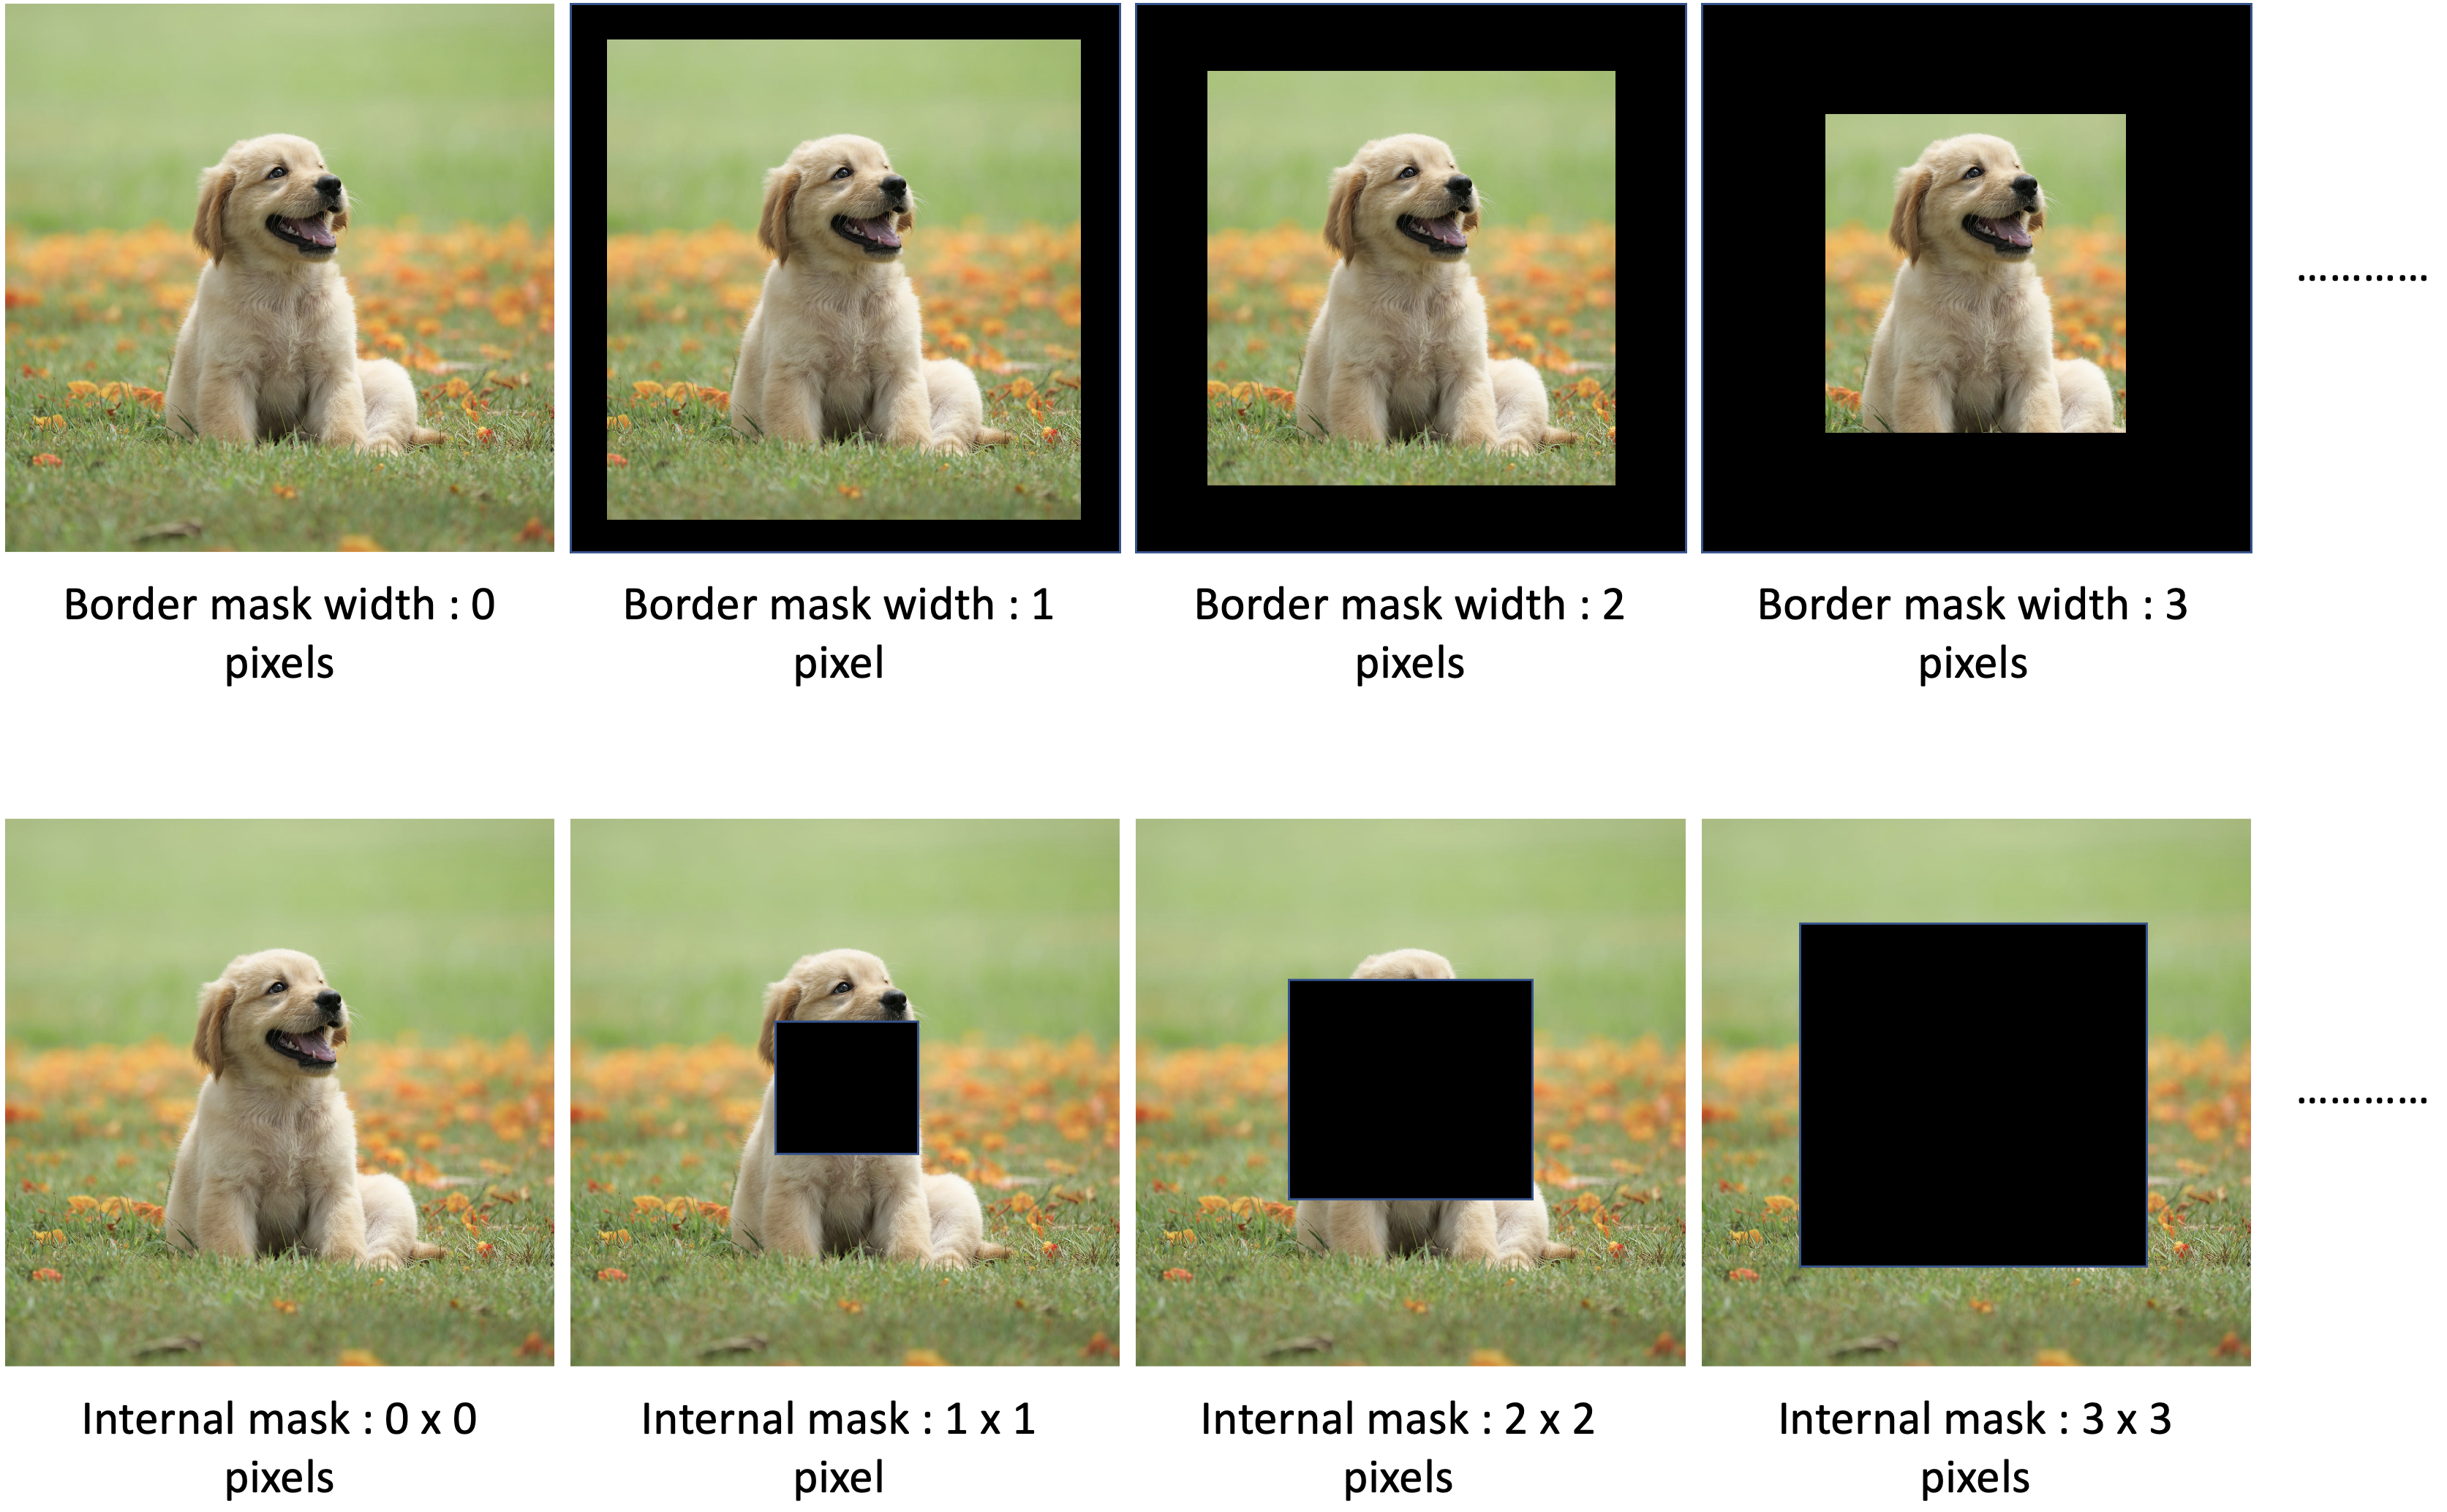

Consider the top case for now (masking in the borders). Your task is to implement the kNN for each case separately. For example, for the case of border mask width = 1 pixel, perform this masking operation to both the training set and test set, and compute kNN classifier's accuracy (which you implemented above) for k = 1. Then, repeat this whole process for increasing levels of border mask width. At the end, you will get a list of kNN accuracies for border mask width = 0 (no masking) to border mask width = 15 pixels (almost complete image has been masked).

Note: border mask width = 16 pixels will be meaningless, as that will mask the whole image.

So, you will have 16 kNN accuracies. Plot them, where x-axis is the border mask width, and y-axis is the kNN accuracy. Analyze that plot, and explain why the plot is the way it is, and what that tells us about the data. Write your code + display the plot + explain your analysis all in this notebook.

Next, repeat the same process for the bottom masking scheme. DO NOT FORGET this part.

For computational efficiency, for all your experiments, you can keep the training and test set size to be 5000 and 500 respectively (just like above).

# Task 3: Testing for homelessness

The term "homelessness" will become clear soon. We will begin with a brief revision of linear classifiers. Refer to lecture 15, slides 6-21. We saw how the (2D) linear classifiers can be geometrically understood as dividing the 2D space into regions belonging to different classes. We also saw how there are some regions which do not belong to any class. Slide 21 depicts a triangular region in the middle that is one such region. In other words, according to the system of linear classifiers given by those three lines (blue, orange, green), any point in the triangular region is "homeless", i,e., does not properly belong to any of the classes. Conversely, a point in any other region belongs to at least one of the classes.

Your task is to formulate a setup to test for homelessness using kNN classifiers. The following two cases can help give you an intuition.

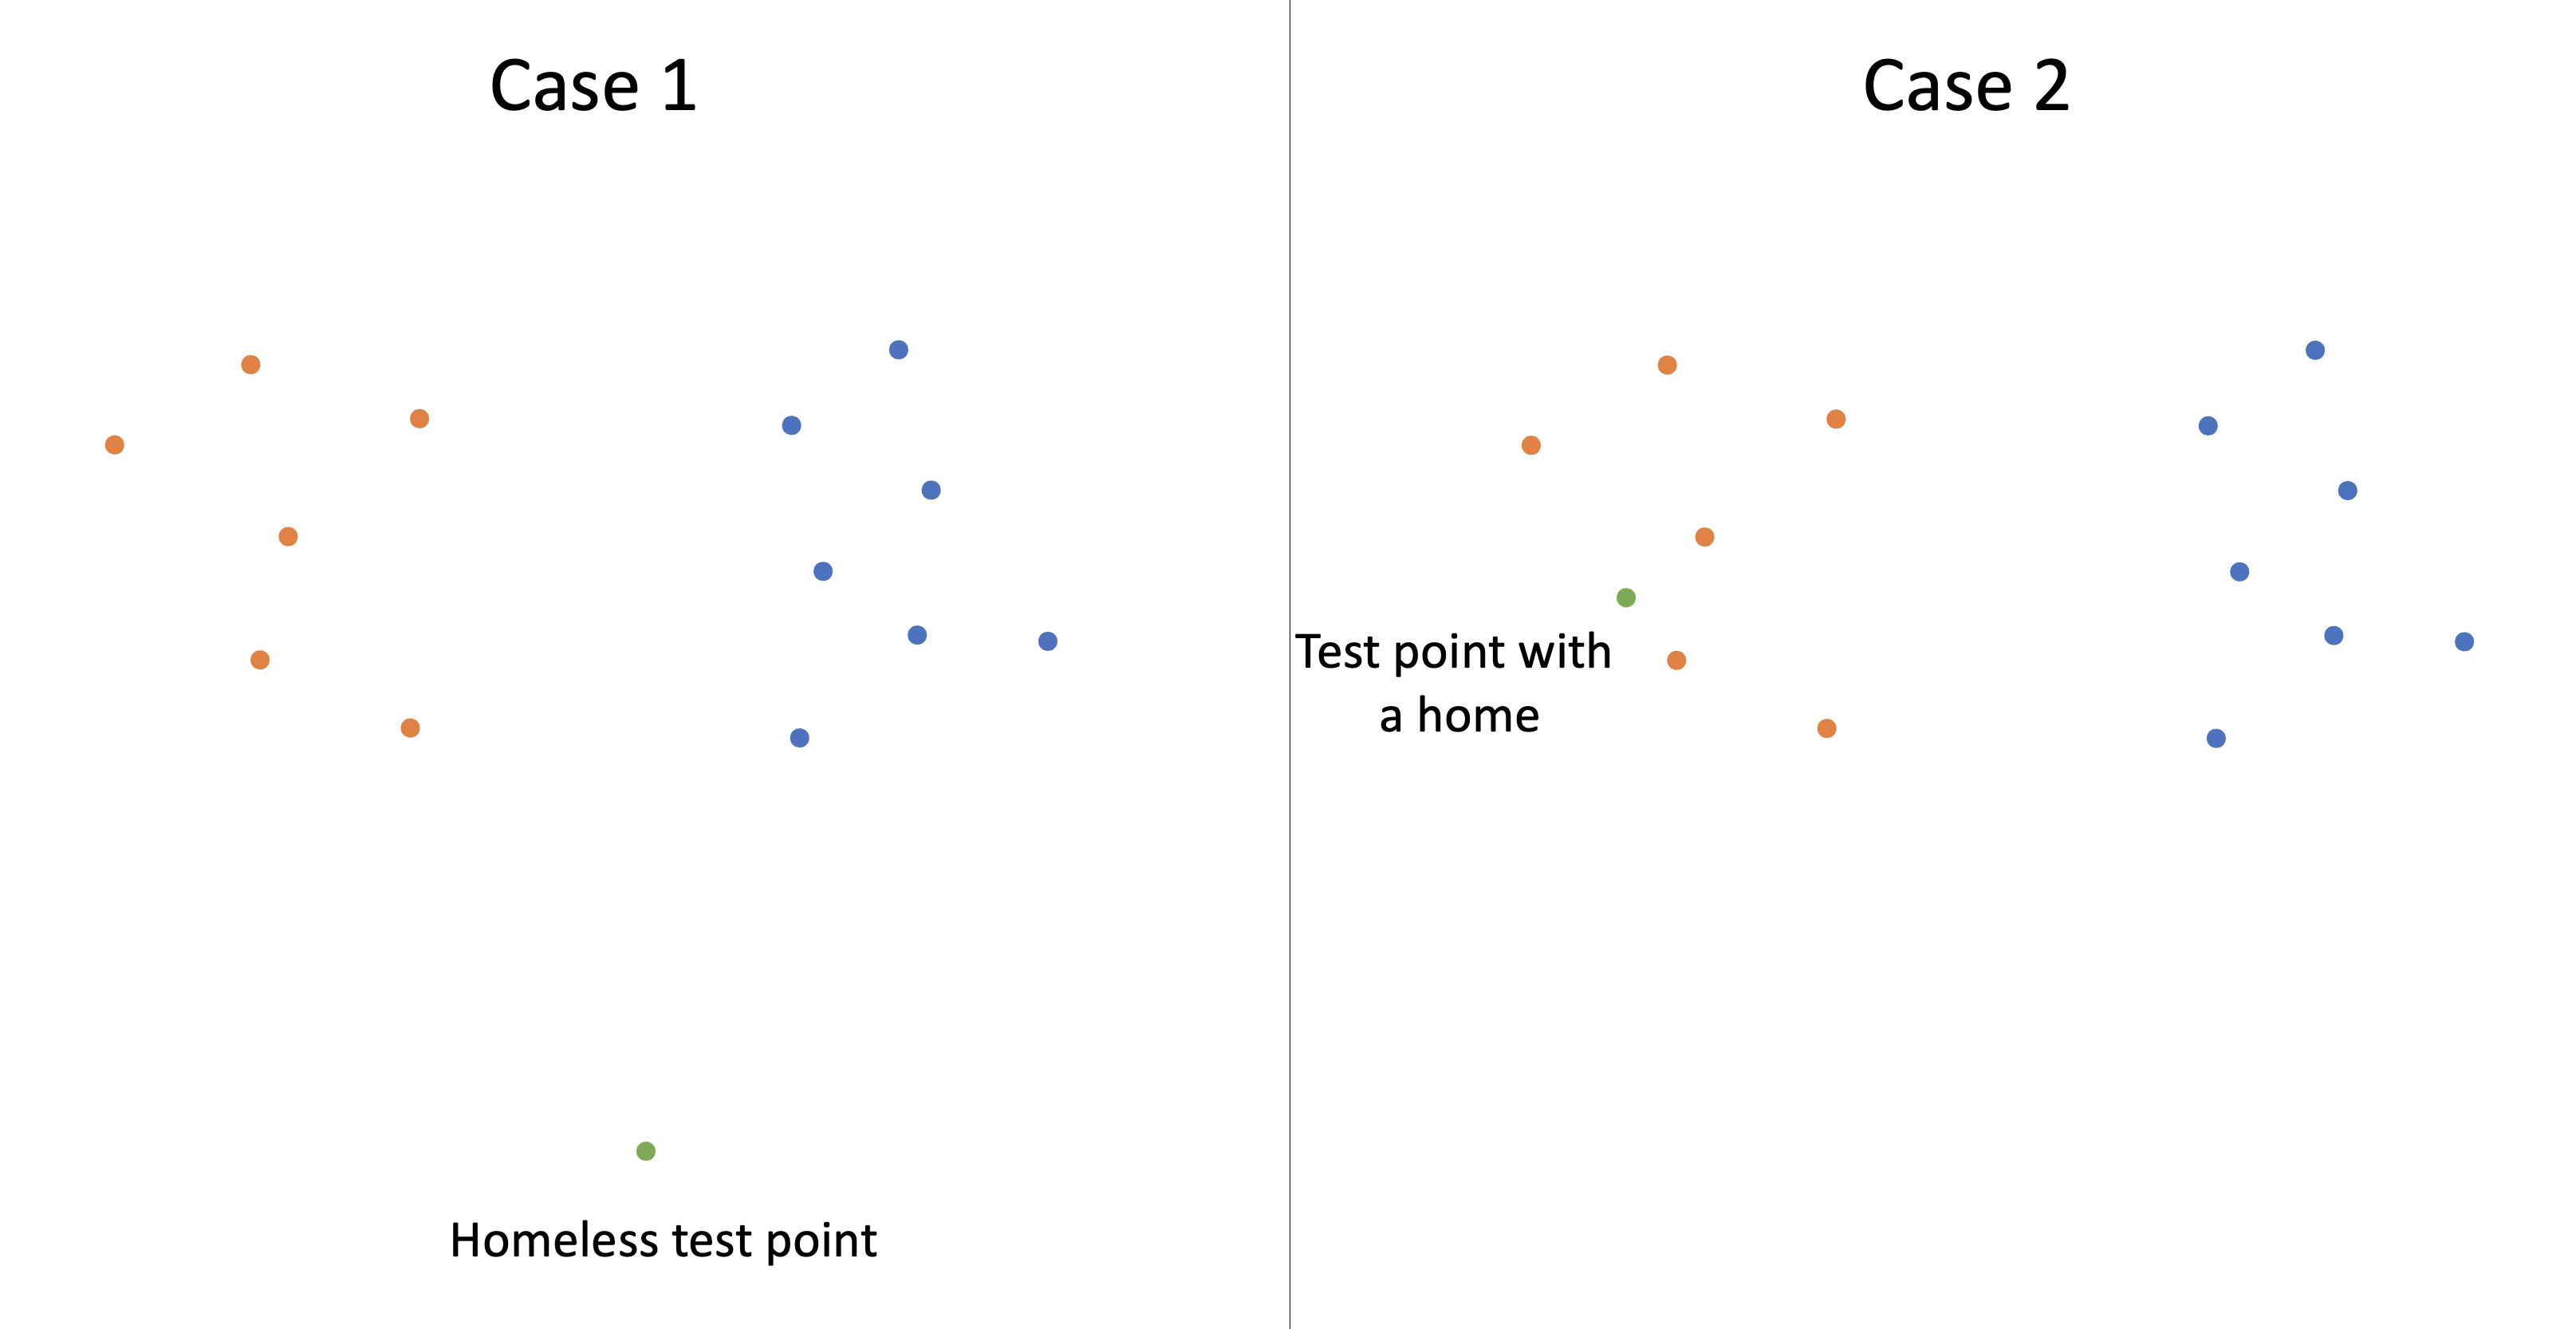

Given points belonging to two classes - orange vs blue - the figure above shows two cases for a test point (green). In case 1, the point is quite far away from all the points and hence can be understood as being homeless. In case 2, it is quit near one of the points from the orange class, hence it properly belongs to the orange class.

Given a training set (orange and blue points) and a test data (green point), you need to write a function that can tell us whether it is homeless or not. Your specific goal is to first explain in English language (with the aid of equations if needed) what the logic of such a function will be. Once you have explained that, you need to implement such a function for the CIFAR dataset. Using the same training and testing set size of 5000 and 500 respectively, compute how many of the 500 test images are homeless. Give some analysis on what that number tells us about the dataset.

It is possible for there to be multiple valid definitions of homelessness. But not every such definition will be valid. For example, here is an ***invalid*** definition.  

*   Measure the closest Euclidean distance of the test point from all the training points
*   If that distance is more than 10.0, then the point is homelees. Otherwise, not homeless.

This definition, relying only on a single absolute distance value is meaningless because it does not consider the distances between other points in the training dataset. Maybe 10.0 is actually very small for a certain collection of points.

# Task 4: Which regions are important for classification?

The CIFAR dataset has images in which there is a foreground, and a background. Sample 5000 training images and 10 random test images. For these test images, find their nearest neighbor. Your task is to analyze which regions, background or foreground, contribute more to the Euclidean distance between a test image and its nearest neighbor.

For example, maybe a test image had a white background and a brown dog as the foreground. Its nearest neighbor turned out to be an image with a white background with a red car in the foreground. You will naturally say that the reason this red car was considered its nearest neighbor was because they have similar background. This can also be validated mathematically, by visualizing the pixel wise Euclidean (L2) difference matrix (refer to lecture 13, slide 15; right most matrix, but for L2 distance). If you view that matrix as a heatmap, you will see that areas having lower L2 difference is the background.

Your task is to perform such an analysis on the 10 random test images. For each of them, explain, through code and visualization, which region is more responsible for lower L2 distance. Is it background, or foreground, or both/neither? Give some commentary on what you are seeing. Is there a pattern among the 10 images, or do all of them have different explanations?

# Task 5: Testing the validity of the curse of dimensionality

In Lecture 14, we talked about the problems when dimensionality of the data increases. Our intuition of distances in such high dimensions start to break down. As a reminder, if one samples some random points in 2D, there will be some points that will be close to each other. And others which will be very far from each other. This distinction of some points being close vs others being far starts getting blurred if you repeat this experiment in higher (e.g., 1000 dimensions) - almost all points are equally far from each other. Refer to Lecture 14, slides 21-28 to go over some of the results which depict this phenomenon.

The data that you have been dealing with so far can easily be considered as very high dimensional data (32 x 32 x 3 = 3072). Your goal is to study how true this curse of dimensionality is for CIFAR dataset using plots similar to those in slides 24-28. The idea is to compute a histogram of pairwise distances between some CIFAR images. Use 5000 if compute is not an issue. If it is, you can use fewer. You need to create two kinds of plots. First one uses Euclidean distance, and the second one uses cosine distance. Note that the slides 24-28 depict the distribution of *angles* between pairs of data points. Cosine distance is `1-cos(angle)`.

Analyze the plot and give your comments on what the key take away is.

# Extra credit (NOT PART OF PROBLEM SET 3)

**Note**: There is no deadline for this extra credit section. People interested in this can work on it till whenever they want until the end of semester and submit me their ideas and solutions through email (not on Canvas).

The CIFAR 10 dataset has duplicates/near-duplicates within it. Around 3.5% of test images have duplicates present in the training set. Read this [article](https://cvjena.github.io/cifair/) (+[paper](https://arxiv.org/pdf/1902.00423)) for more details.

The authors in the paper used some sophisticated techniques to do nearest neighbor searach to find such duplicates. I use the term sophisticated because even though the algorithm to conduct the search was the same as what we have discussed, it was not done in the pixel space, but in a much better, compressed space in which distances are more meaningful (remember the curse of dimensionality). That is, the images are first transformed into a compressed space. We will learn about that later on in this course.

Your task is to see if at least some of those duplicates that these authors found through their fancy nearest neighbor search can be found using some tricks in our own implementation of this assignment. Some modifications will need to be done - the same pixel space nearest neighbor search won't help you find the duplicates which, for example, are shifted left by a few pixels (Lecture 14, slides 19-20). I am purposefully leaving things open ended as are completely free in how you wish to attempt this problem.

Since there is no gurantee that a solution might exist which can recover a big portion of the duplicates found by the paper mentioned above, I will be pretty liberal in how I will grade this section. If I can see that you have put in a genuine attempt at this, rest assured that I will not let it go unawarded. You can gain up to **40 points** that can be used to cover deficit in your grades for problem sets 1-4. Please do not assume that anyone who writes a few lines of code as an attempt will straight away get 40 points. Unless those few lines of code actually do the task.

You are, of course, free to ask me more details, and also if you need some guidance.

Again, no submission required for problem set 3. This section will be graded separately.